In [1]:
from aoespy import *

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import ecco_v4_py as ecco
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob
import os

In [3]:
import xarray as xr

In [4]:
def readmit(exp='GEOSMIT35_ctrl',loc='/nobackupp27/afahad/exp/',file='state_3d_set1',var=1,start_date='20050501',nfiles=120,freq='D',nz=50, nf=6, ni=90, nj=90, ntile=13,expdir='../mit_output/'):
    
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    os.chdir(loc+exp+'/plot')
    pdir='../plots_CLIM/ocean_mit/'
    vdir='/nobackupp27/afahad/mit_diag/'
    try:
        os.system('mkdir -p '+pdir)
    except:
        None

    bathy = ecco.read_llc_to_tiles(input_dir, input_file)

    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')


    
    restarts='../restarts/'

    os.chdir(expdir)
    files=np.array(sorted(glob(file+'*.data'))[0:nfiles])
    time=pd.date_range(start_date,periods=len(files),freq=freq)
    
    djf_files=files

    nt=len(time); 

    ndjf=len(djf_files)

    theta_djf=np.zeros((ndjf,nz,ntile,nj,ni)); theta_djf[:]=np.nan
    
    print('reading files')
    for i in range(ndjf):
        print(djf_files[i])
        data=ecco.read_llc_to_tiles(expdir, djf_files[i], nk=-1,nl=-1)
        print(data.shape)
        data=np.reshape(data, (nf,nz,ntile,nj,ni))
        theta_djf[i,:,:,:]=data[var,:,:,:,:]
    return (theta_djf, time)
    
def llc2grd(theta_djf,nz=50):
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')
    theta_djf_all=np.zeros(theta_djf.shape)
    theta_djf_all[:]=theta_djf

    new_grid_delta_lat = 1
    new_grid_delta_lon = 1

    new_grid_min_lat = -90
    new_grid_max_lat = 91

    new_grid_min_lon = -180
    new_grid_max_lon = 180

    new_lat=np.arange(-90,91,1); nlat=len(new_lat)
    new_lon=np.arange(-180,180,1); nlon=len(new_lon)

    tt=len(theta_djf)
    theta_djf_alli=np.zeros((tt,nz,nlat,nlon))

    for i in range(tt):
        for j in range(nz):

            new_grid_lon_centers, new_grid_lat_centers,\
            new_grid_lon_edges, new_grid_lat_edges,\
            theta_djf_alli[i,j,:,:] =\
                    ecco.resample_to_latlon(ecco_grid.XC, \
                                            ecco_grid.YC, \
                                            theta_djf_all[i,j,:,:,:],\
                                            new_grid_min_lat, new_grid_max_lat, new_grid_delta_lat,\
                                            new_grid_min_lon, new_grid_max_lon, new_grid_delta_lon,\
                                            fill_value = np.NaN, \
                                            mapping_method = 'nearest_neighbor',
                                            radius_of_influence = 120000)
    return (np.squeeze(theta_djf_alli), new_lon, new_lat)


In [51]:

ME506o, time=readmit('GEOSMIT_ME0506',file='state_3d_set1',var=2,nz=50,nfiles=64,nf=6,freq='12H',start_date='20050506', )
ME506o=ME506o[:,0:1,:,:,:]
ME506o,lon,lat=llc2grd(ME506o,nz=1)

RP506o, time=readmit('GEOSMIT_RP0506',file='state_3d_set1',var=2,nz=50,nfiles=64,nf=6,freq='12H',start_date='20050506', )
RP506o=RP506o[:,0:1,:,:,:]
RP506o,lon,lat=llc2grd(RP506o,nz=1)

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_3d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000000156.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000000156.data
load_binary

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001788.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001788.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000001884.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000001884.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003516.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003516.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000003612.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000003612.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005244.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005244.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000005340.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000005340.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000016668.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000016668.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000016764.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000016764.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000018396.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000018396.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000018492.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000018492.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000020124.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000020124.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000020220.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000020220.data
load_binary_array: loading all 2D records.  nk = 300
load_

load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000021852.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000021852.data
load_binary_array: loading all 2D records.  nk = 300
load_binary_array: data array shape  (300, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (300, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (300, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(300, 13, 90, 90)
state_3d_set1.0000021948.data
load_binary_array: loading file ../mit_output/state_3d_set1.0000021948.data
load_binary_array: loading all 2D records.  nk = 300
load_

In [52]:
ds = xr.Dataset(
    {
        "ME506": (["time", "lat", "lon"], ME506o),
        "RP506": (["time", "lat", "lon"], RP506o)
    },
    coords={
        "time": time,
        "lat": lat,
        "lon": lon
    }
)


ME506o=ds.ME506.sel(time=slice('2005-05-06','2005-07-02'))
RP506o=ds.RP506.sel(time=slice('2005-05-06','2005-07-02'))

In [53]:
ticks=[]

for i in range(len(ME506o.time)):
    ticks=append(ticks,str(ME506o.time.data[i])[5:10])

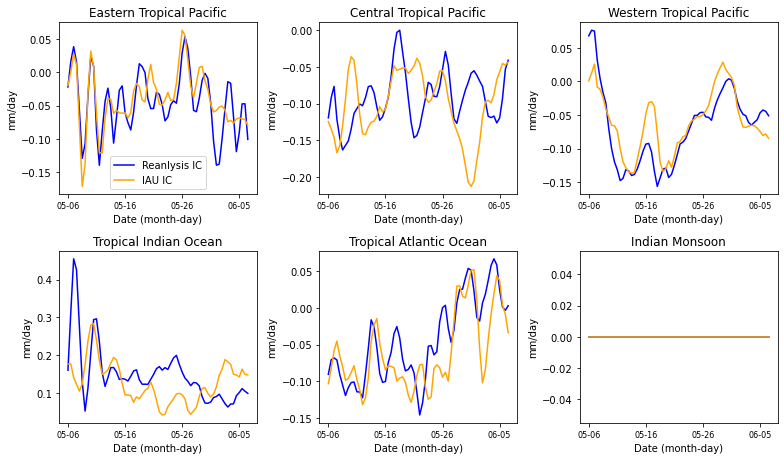

In [54]:

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))
plt.subplot(2,3,1)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

# x1=136
# x2=137
# y1=3
# y2=4

x1=143
x2=143
y1=-1
y2=-1

plt.subplot(2,3,3)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=89
x2=92
y1=7
y2=8



plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=-39
x2=-38
y1=7
y2=8



plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=90
x2=91
y1=23
y2=25

plt.subplot(2,3,6)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Indian Monsoon')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=32
x2=35
y1=-1
y2=2



plt.tight_layout()
#plt.savefig('spike_pr.png',dpi=150)

In [30]:
RP506=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')
RP5062=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
RP5063=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')

In [31]:
ME506=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')
ME5062=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
ME5063=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')


In [32]:
RP506=xr.concat([RP506,RP5062,RP5063],dim='time')
ME506=xr.concat([ME506,ME5062,ME5063],dim='time')

In [35]:
RP506a=RP506[['TAUX','TAUY','US', 'VS']].sel(time=slice('2005-05-06','2005-07-02')).compute()
ME506a=ME506[['TAUX','TAUY','US', 'VS']].sel(time=slice('2005-05-06','2005-07-02')).compute()

In [64]:
RP506=RP506a.US.resample(time='1D').mean()
ME506=ME506a.US.resample(time='1D').mean()

In [65]:
ticks=[]

for i in range(len(ME506.time)):
    ticks=append(ticks,str(ME506.time.data[i])[5:10])

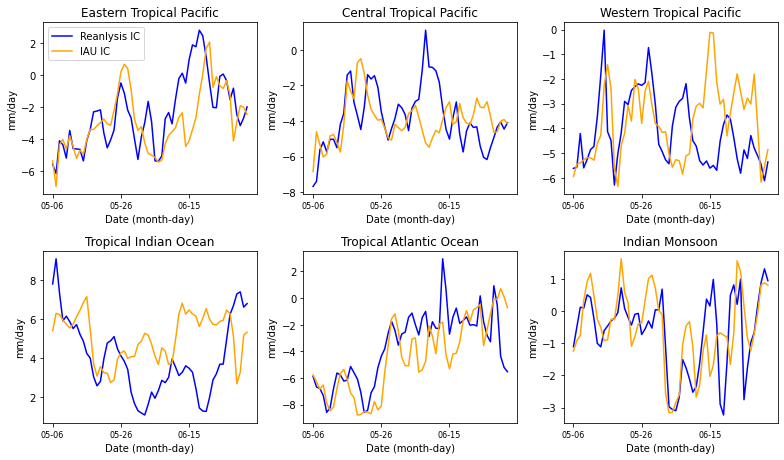

In [66]:

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))
plt.subplot(2,3,1)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

# x1=136
# x2=137
# y1=3
# y2=4

x1=143
x2=143
y1=-1
y2=-1

plt.subplot(2,3,3)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=89
x2=92
y1=7
y2=8



plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=-39
x2=-38
y1=7
y2=8



plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=90
x2=91
y1=23
y2=25

plt.subplot(2,3,6)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Indian Monsoon')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=32
x2=35
y1=-1
y2=2



plt.tight_layout()
#plt.savefig('spike_pr.png',dpi=150)

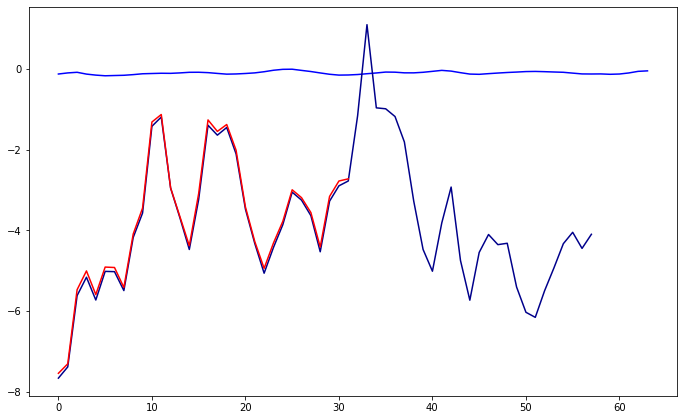

In [68]:
x1=-178
x2=-178
y1=2
y2=2

f()

plt.plot((ME506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='darkblue')
plt.plot((ME506-ME506o).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')